This file acts as a playground to determine f.e. the ideal Interval for the Analysis

In [138]:

Patient = "P032" #"P015/P015_S01_D2024-07-06"
run = "S01"
date = "2024-12-12"

2026-01-14 21:47:37,419 - INFO - Using device: mps
2026-01-14 21:47:37,919 - INFO - Loaded primary TDMS file: Data/P032/P032_S01_D2024-12-12.tdms
2026-01-14 21:47:38,172 - INFO - Loaded additional TDMS file: Data/P032/P032_S01_D2024-12-12_addCh.tdms
2026-01-14 21:47:38,174 - INFO - Loaded sensor log file: Data/P032/QZFM_log_file.txt
2026-01-14 21:47:38,174 - INFO - Available runs: Brustlage, Rueckenlage
2026-01-14 21:47:38,808 - INFO - Model loaded successfully from MCG_segmentation/trained_models/UNet_1D_15M/checkpoints/acm_study_checkpoint/model.pth


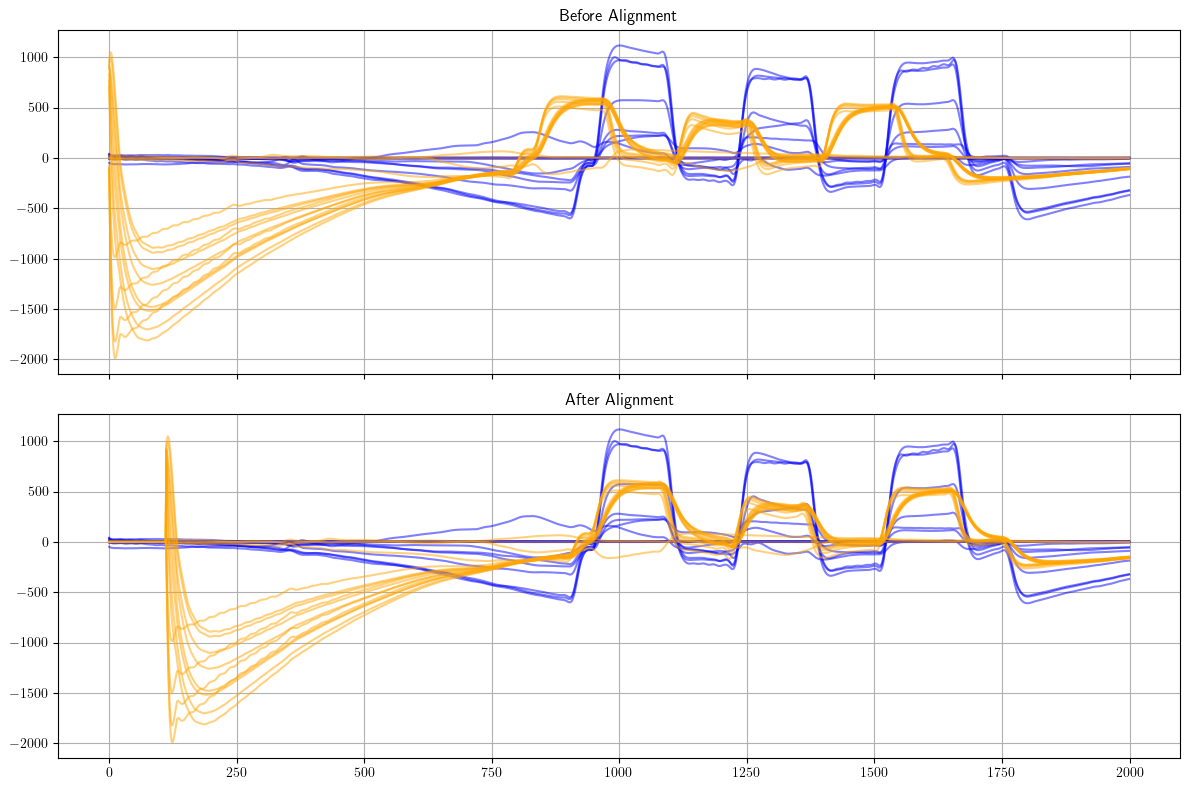

2026-01-14 21:47:40,768 - INFO - Resampling data from 1000Hz to 250Hz. Target length: 73148, Original length: 292592 samples.


In [139]:
import importlib
import analyzer
importlib.reload(analyzer)
from analyzer import Analyzer
import matplotlib.pyplot as plt
import pandas as pd
import re
import os
import json
import numpy as np




analysis = Analyzer(
        filename=f"Data/{Patient}/{Patient}_{run}_D{date}.tdms",
        add_filename=f"Data/{Patient}/{Patient}_{run}_D{date}_addCh.tdms",
        log_file_path=f"Data/{Patient}/QZFM_log_file.txt",
        sensor_channels_to_exclude={
          "Bauchlage": [],
          "Rueckenlage": []
        },
        #model_checkpoint_dir=f"MCG_segmentation/trained_models/UNet_1D_900k",
    )

key = "Brustlage"  # "Bauchlage", "Brustlage", "Rechtslage", "LinksLage"
(x_data, y_data, z_data), time, single_run = analysis.prepare_data(key, apply_default_filter=True, align=True, plot_alignment=True)




# Find fitting intervall

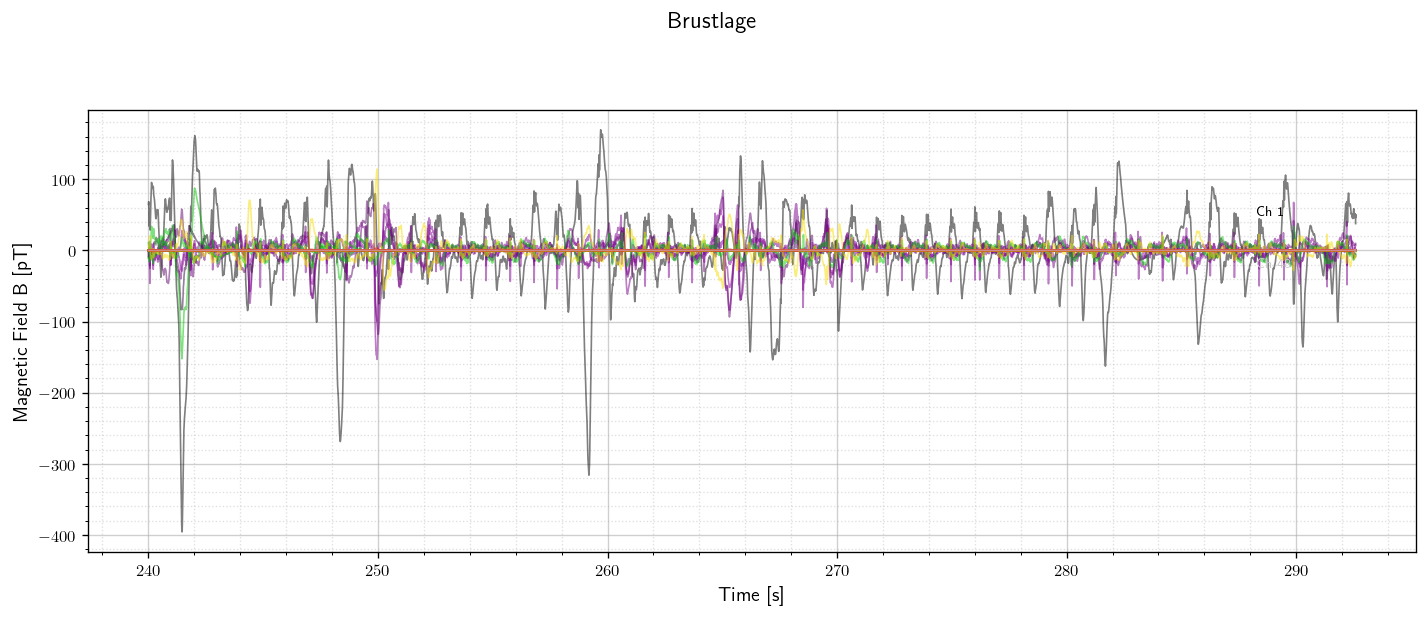

In [142]:
intervall_start = 60000
intervall_end =  -1


analysis.butterfly_plot(single_run[: :, intervall_start:intervall_end], time[intervall_start:intervall_end], single_run.shape[0], "Brustlage")

## Apply ICA filtering 

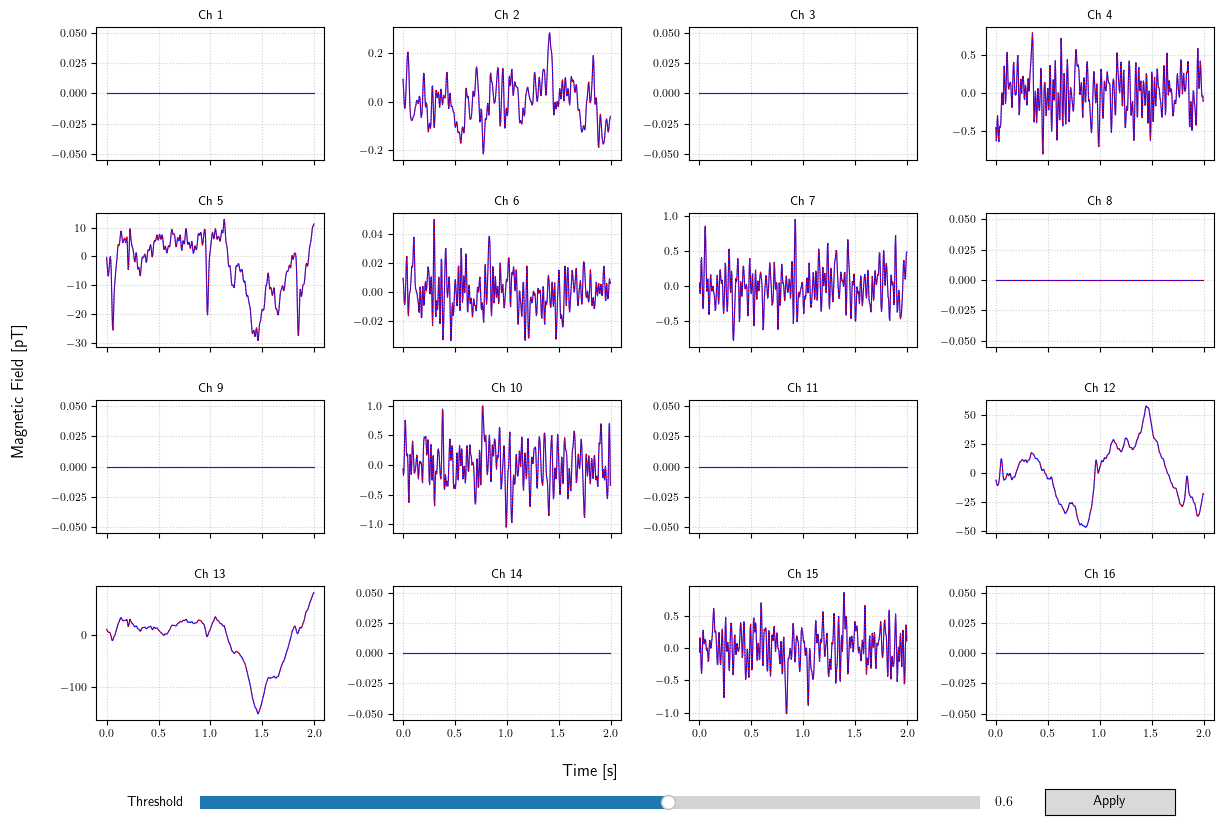

/Volumes/Riesenspeicher/Projekte/Bachelor/Bachelorarbeit/venv/lib/python3.11/site-packages/sklearn/decomposition/_fastica.py:127: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(


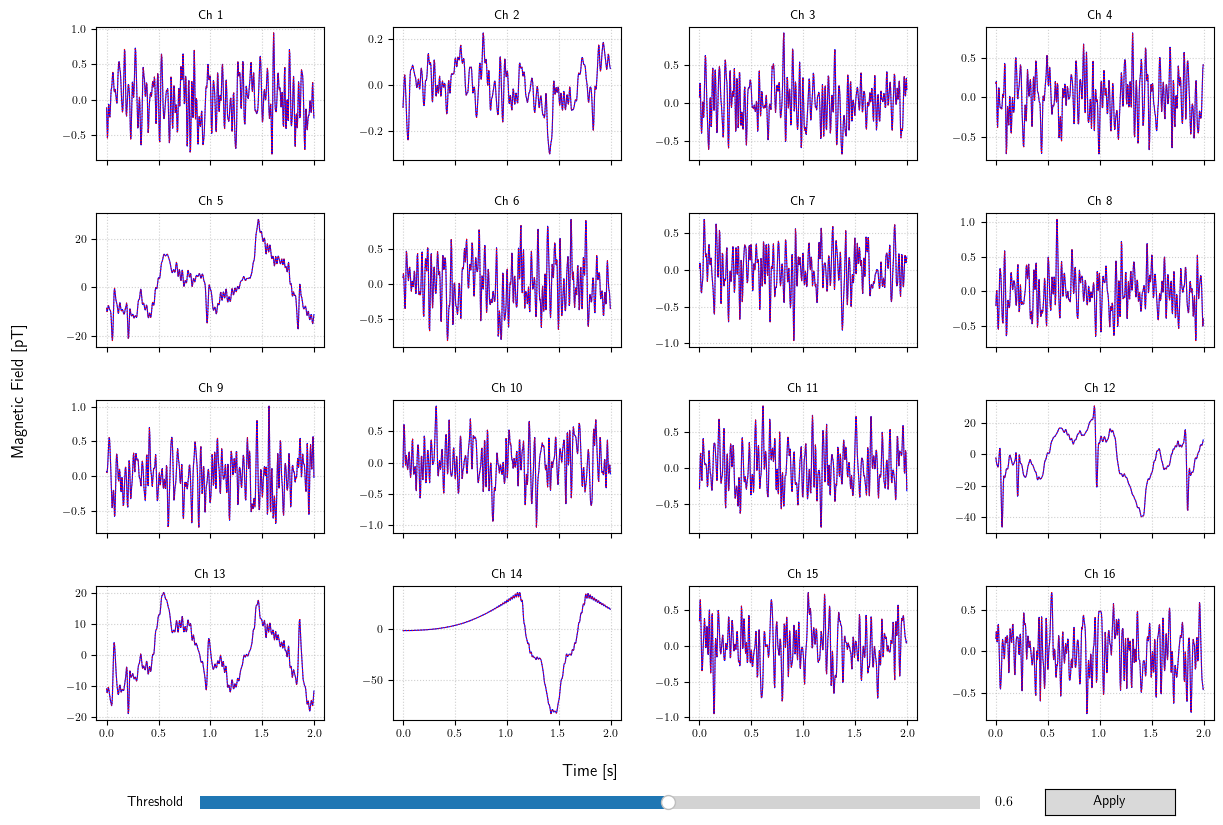

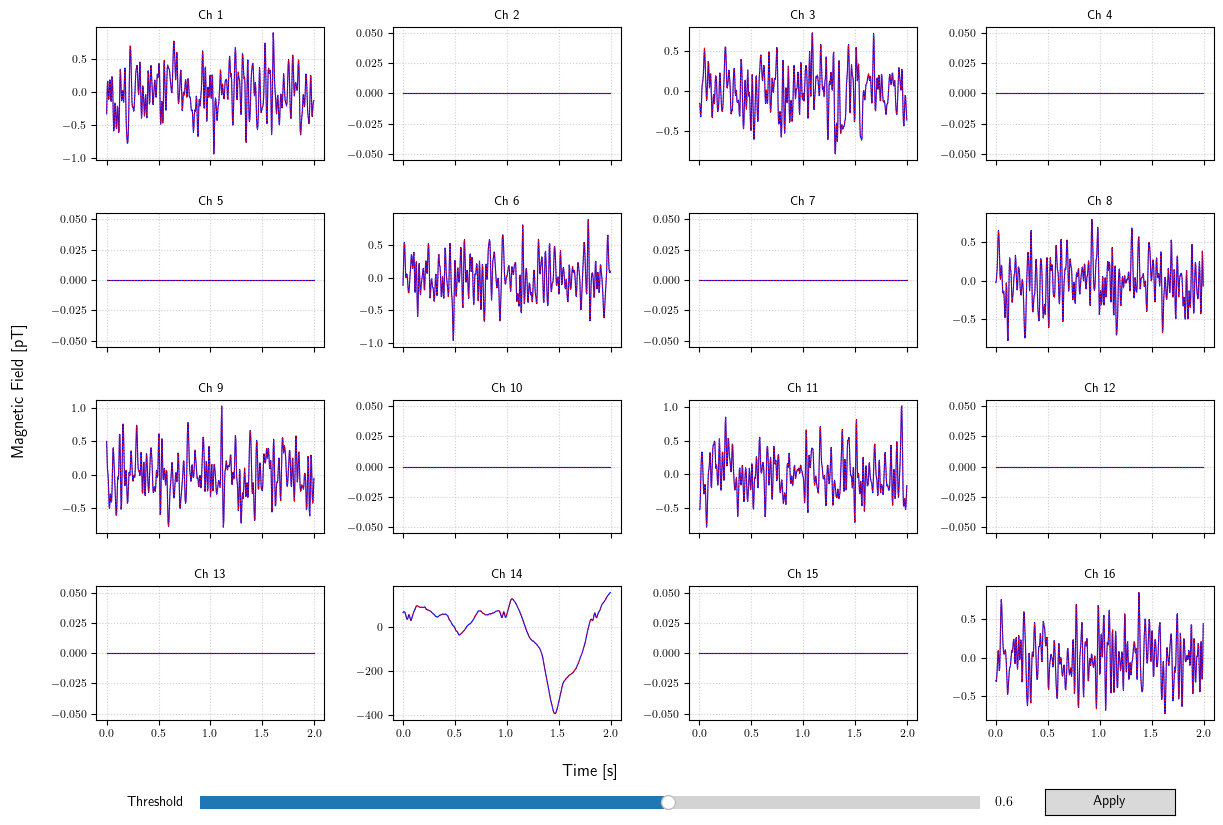

In [143]:


x_data_intervall = x_data[:, :, intervall_start:intervall_end]
y_data_intervall = y_data[:, :, intervall_start:intervall_end]
z_data_intervall = z_data[:, :, intervall_start:intervall_end]
time_intervall = time[intervall_start:intervall_end]
single_run_intervall = single_run[:, intervall_start:intervall_end]


#analysis.plot4x4(z_data[:, :, 250:1250], time[250:1250], name="z_data")

x_data_filtered, _, _, _ = analysis.ICA_filter(x_data_intervall, heart_beat_score_threshold=0.60, plot_result=True)
y_data_filtered, ica_components, _, _ = analysis.ICA_filter(y_data_intervall, heart_beat_score_threshold=0.60, plot_result=True)
z_data_filtered, _, _, _ = analysis.ICA_filter(z_data_intervall, heart_beat_score_threshold=0.60, plot_result=True)

#print(ica_components.shape)
#analysis.plot_sensor_matrix(ica_components[:, :500].reshape(4, 4, -1), time_intervall[:500], name="ica_components")

Improve Windowing

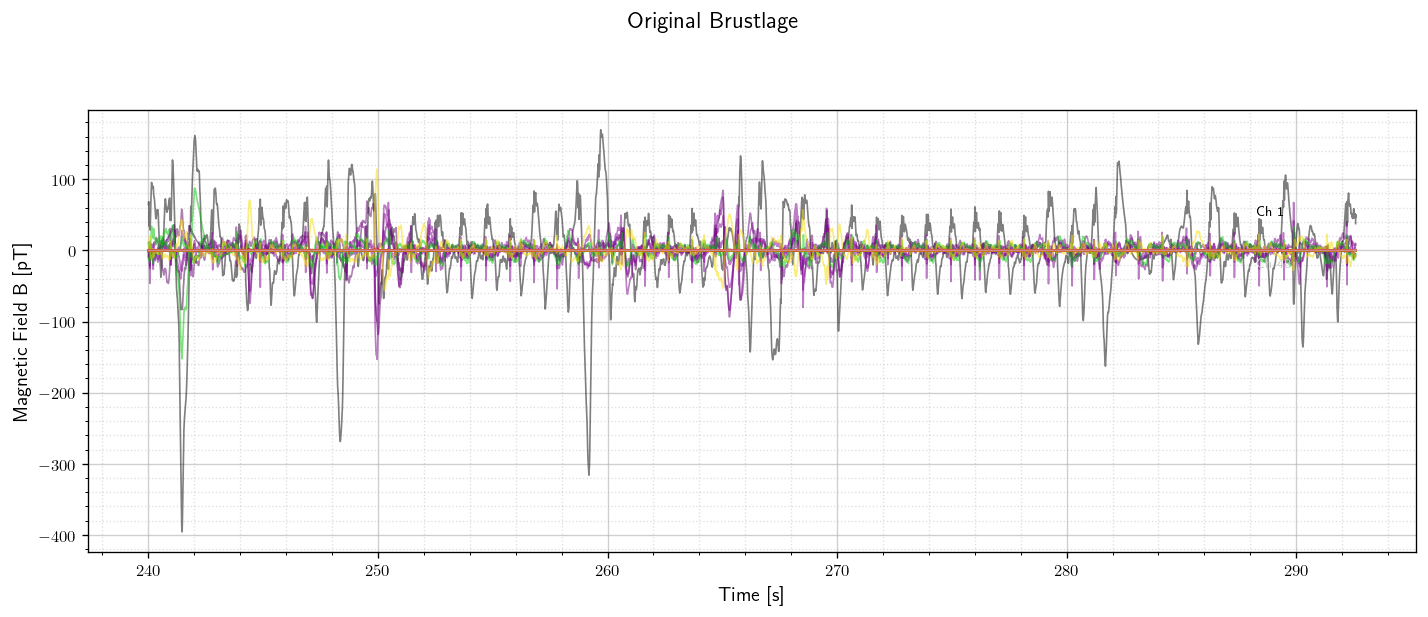


Channel Selection Results:
Channel   Conf        P-Wave %    QRS %       T-Wave %    Plausibility   Final Score 
-------------------------------------------------------------------------------------
1         0.6775      0.09        1.49        10.56       0.3465         0.6113      
2         0.6317      1.05        3.81        13.43       0.4402         0.5934      
3         0.6951      1.83        10.96       23.00       0.6183         0.6797      
4         0.7617      3.68        10.91       22.96       0.6984         0.7491      
5         0.7416      2.70        10.30       21.78       0.6536         0.7240      
6         0.6996      2.59        10.91       20.04       0.6491         0.6895      
7         0.6689      0.00        5.51        3.26        0.3103         0.5971      
8         0.6777      0.36        5.99        3.38        0.3198         0.6062      
9         0.6772      0.11        4.53        3.20        0.3016         0.6021      
10        0.6756      0.08

2026-01-14 21:48:34,590 - INFO - Heart Rate: 57.35 bpm
2026-01-14 21:48:34,591 - INFO - Heart Rate Variability (SDNN): 257.73 ms
2026-01-14 21:48:34,591 - INFO - Number of detected peaks: 50
2026-01-14 21:48:34,591 - INFO - Number of plausible RR intervals used: 49


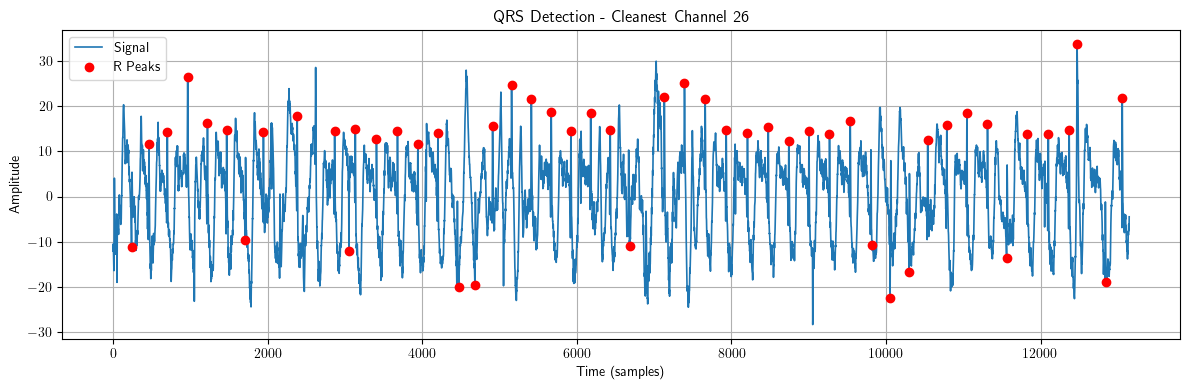

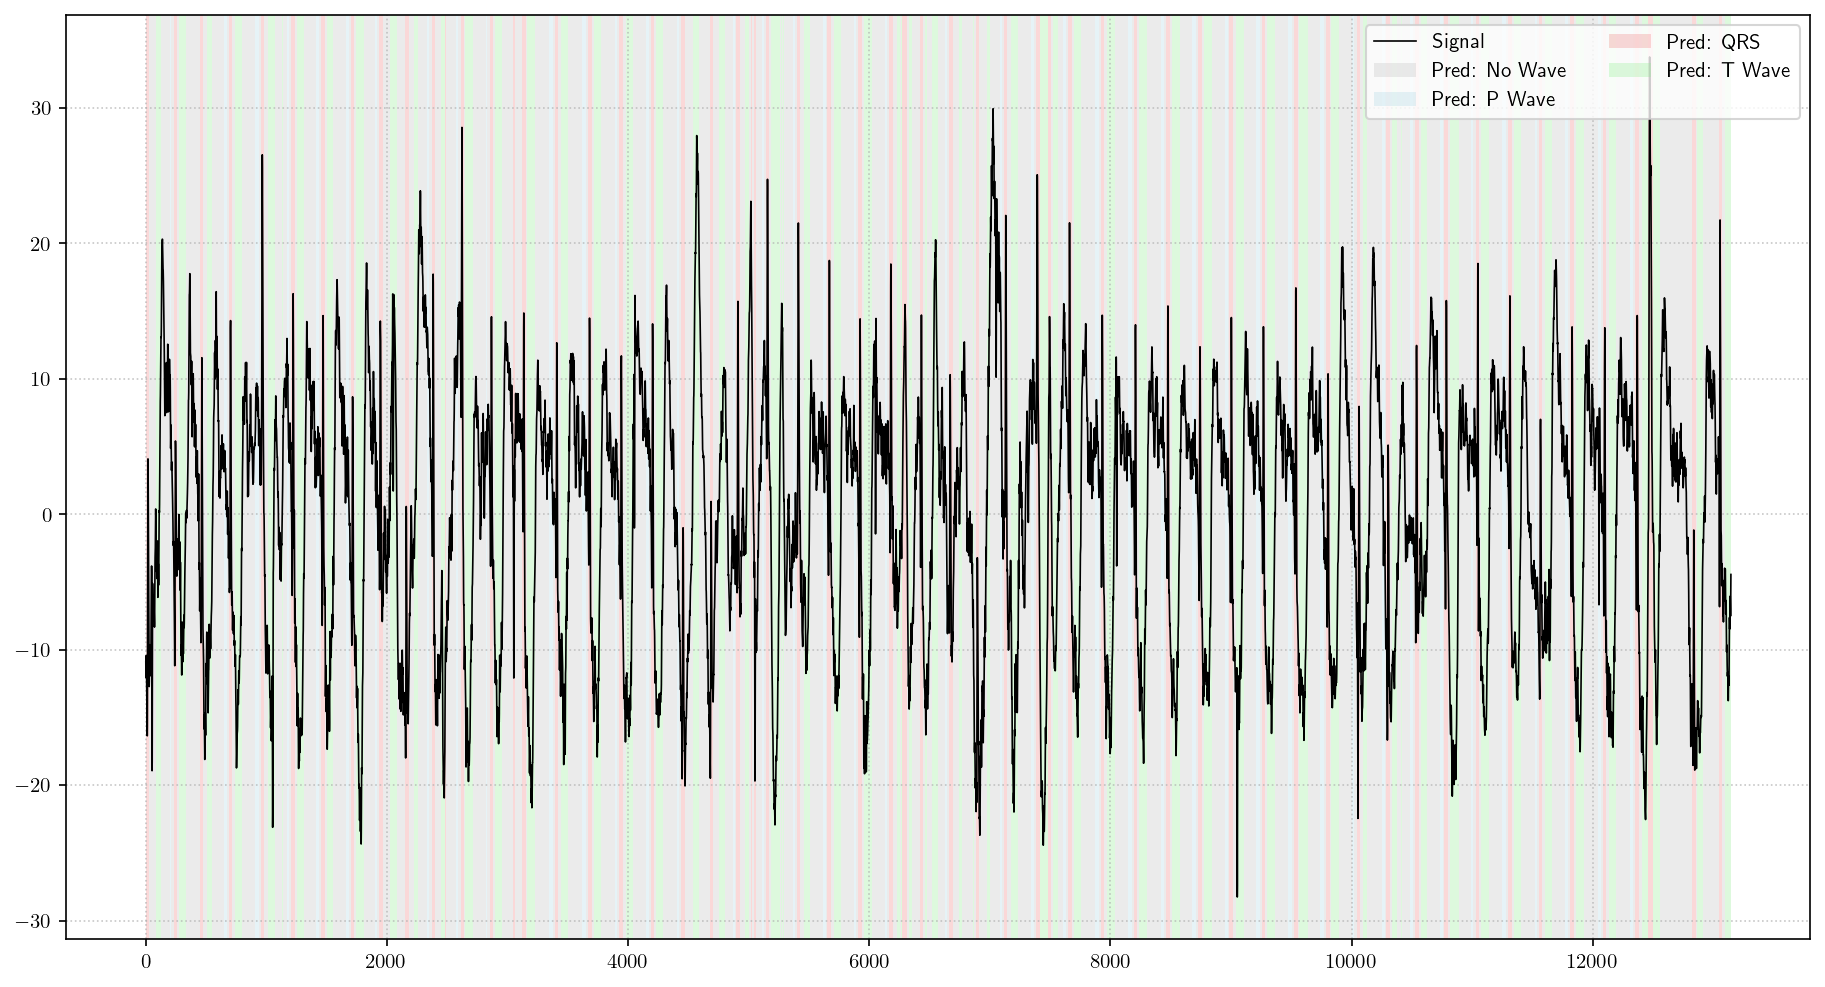

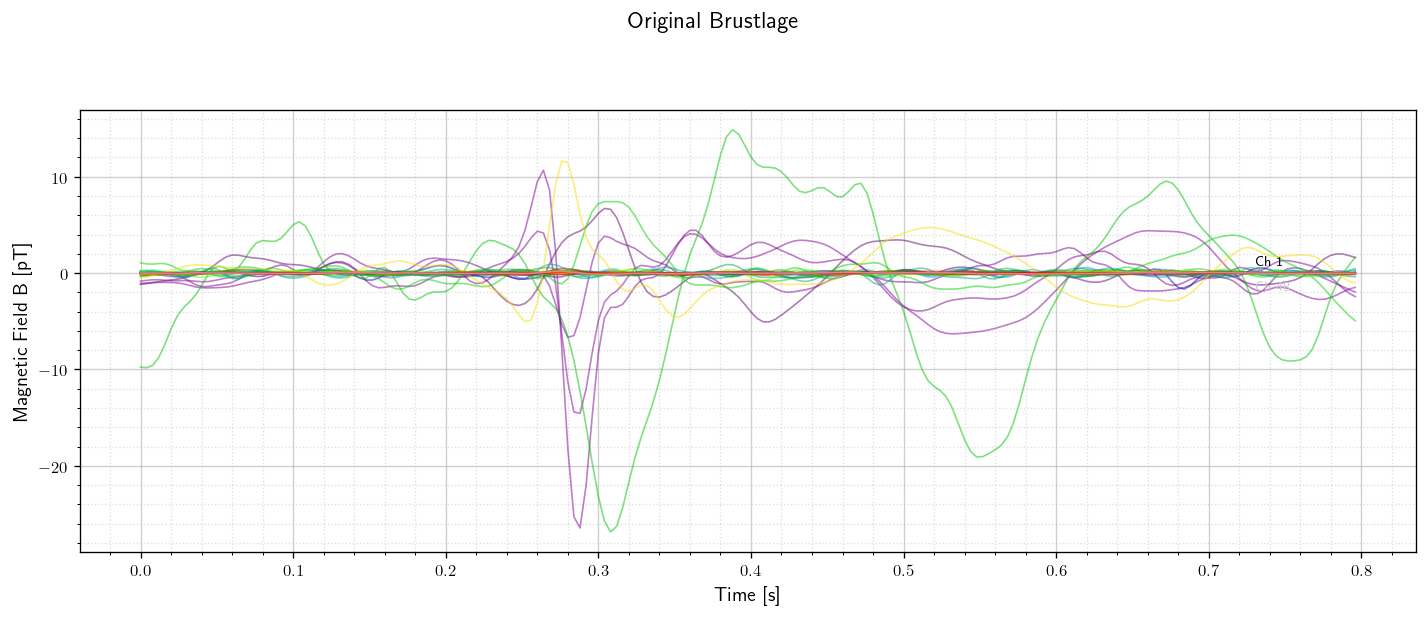

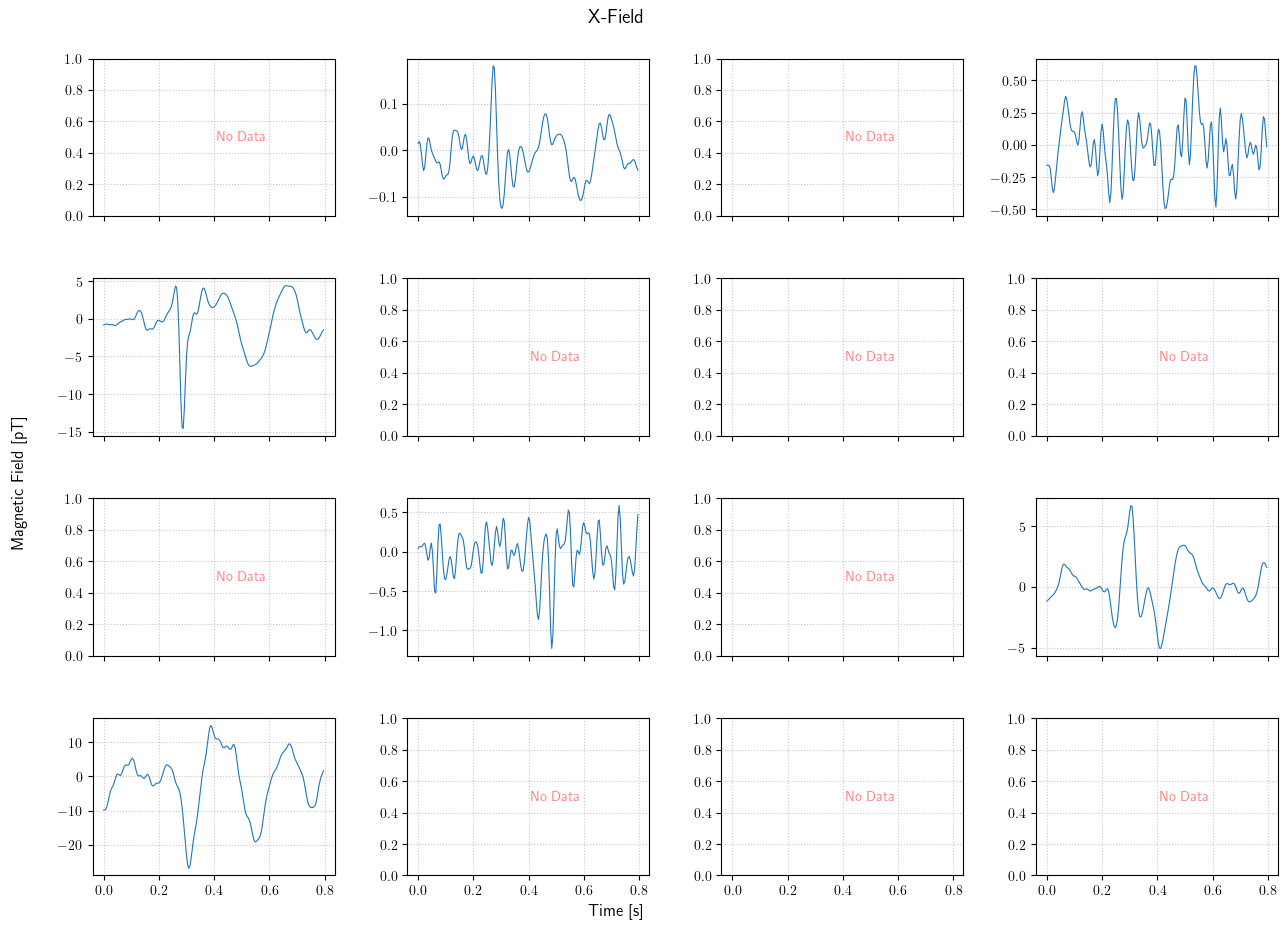

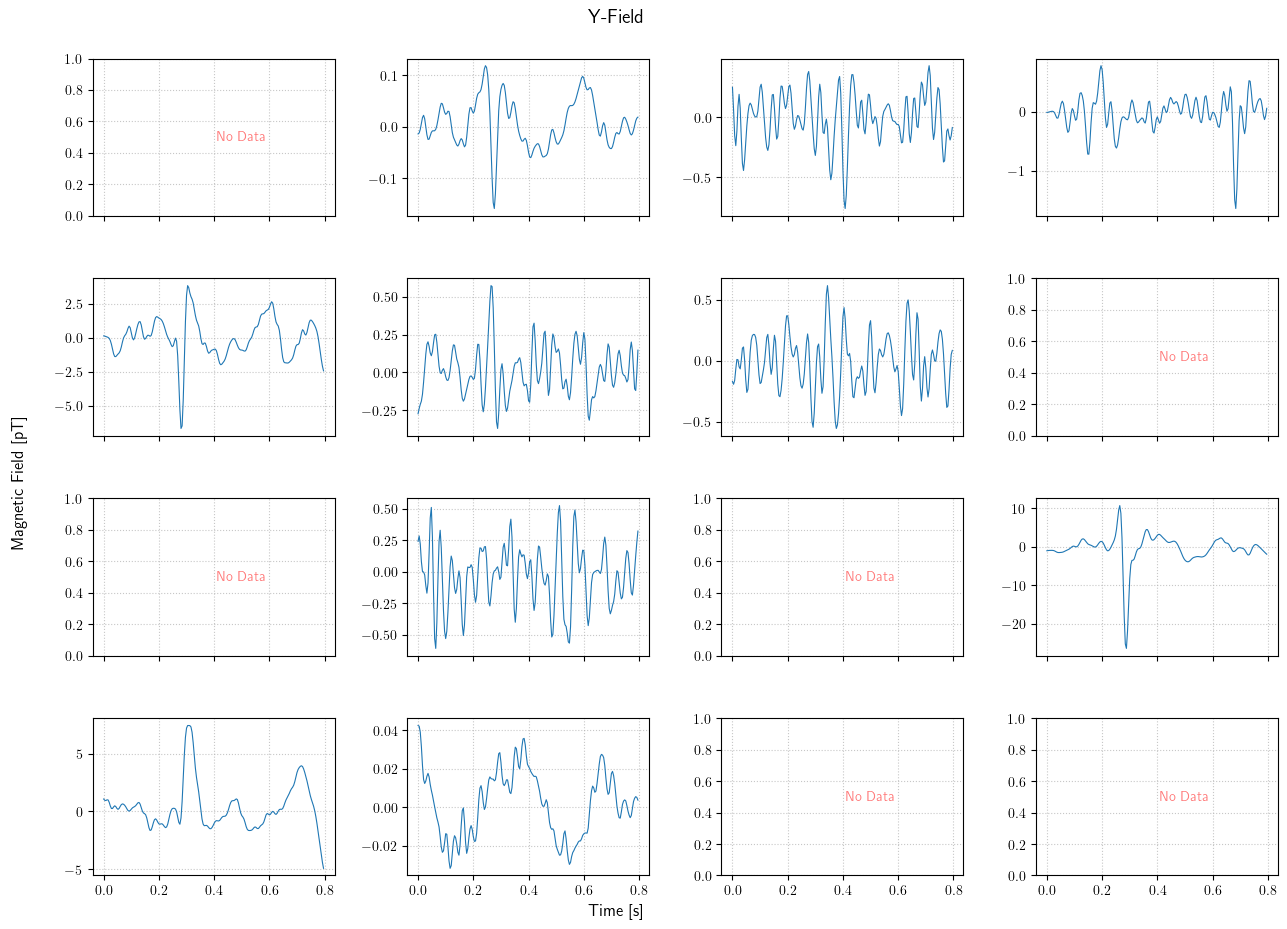

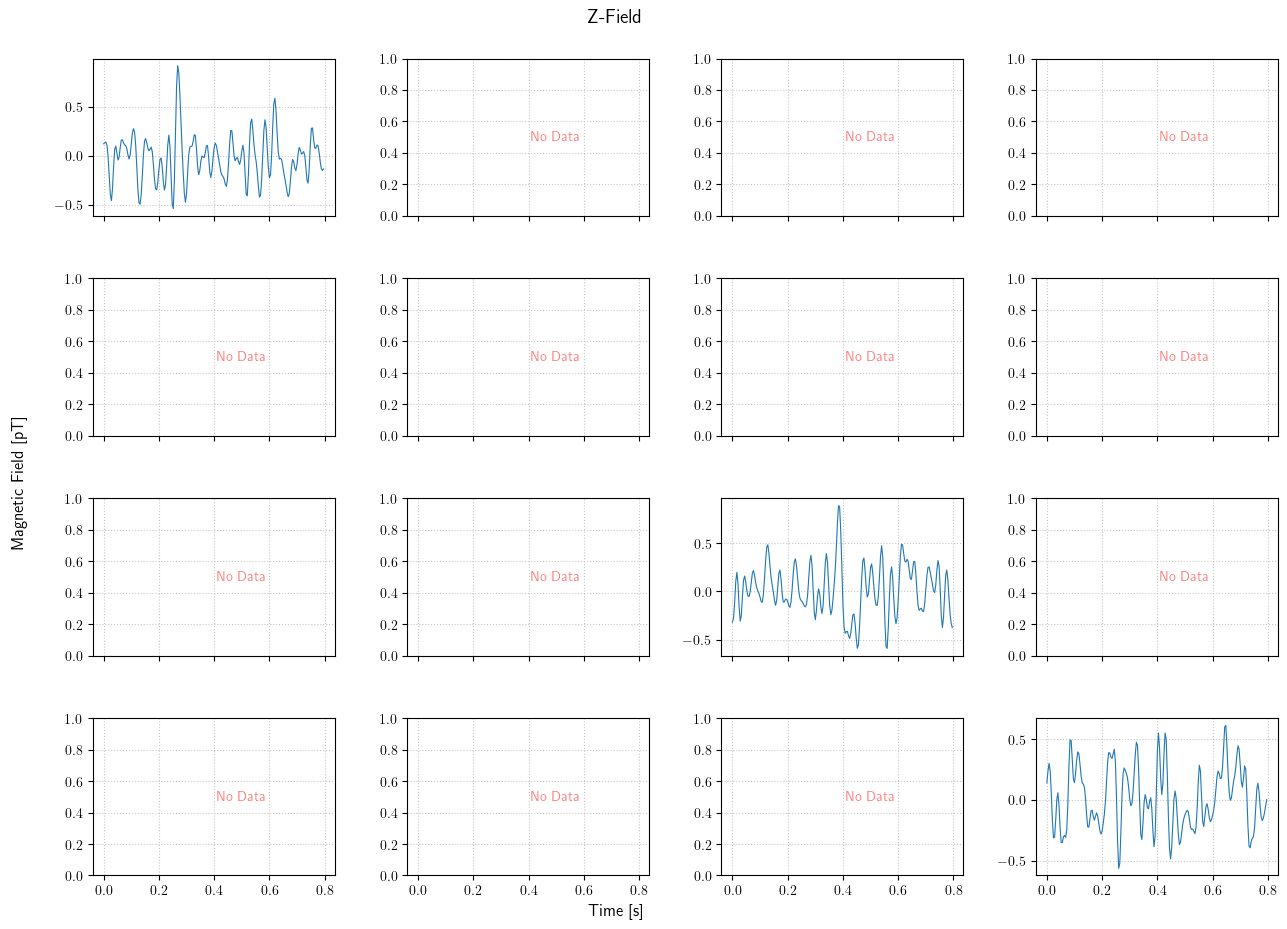

In [144]:
single_run_filtered = single_run_intervall#analysis.invert_field_directions(x_data_filtered, y_data_filtered, z_data_filtered, key, 48)


analysis.butterfly_plot(single_run_filtered, time_intervall, 48, f"Original {key}")


analysis.find_cleanest_channel(single_run_filtered)

# use cleanest channel for peak detection
peak_positions, ch, labels, _, _ = analysis.detect_qrs_complex_peaks_cleanest_channel(single_run_filtered, print_heart_rate=True, confidence_threshold=0.7, confidence_weight=1, plausibility_weight=0)
if peak_positions is not None and len(peak_positions) > 0:
    plt.figure(figsize=(12, 4))
    plt.plot(single_run_filtered[ch, :], label='Signal', linewidth=1.2)
    #plt.plot(resampled_data[ch, :], label='Signal', linewidth=1.2)
    plt.plot(peak_positions, single_run_filtered[ch, peak_positions], "ro", markersize=6, label='R Peaks')
    plt.title(f"QRS Detection - Cleanest Channel {ch + 1}")
    plt.xlabel("Time (samples)")
    plt.ylabel("Amplitude")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print("No R peaks detected or `peak_positions` is empty.")
analysis.plot_segmented_signal(single_run_filtered[ch, :], labels[ch, :])


# window averaging
avg_channels, time_window = analysis.avg_window(single_run_filtered, peak_positions, window_left=0.3, window_right=0.5)
analysis.butterfly_plot(avg_channels, time_window, 48, f"Original {key}")


x_data_window, y_data_window, z_data_window = analysis.get_field_directions(avg_channels, key)

analysis.plot_sensor_matrix(x_data_window, time_window, name="X-Field")
analysis.plot_sensor_matrix(y_data_window, time_window, name="Y-Field")
analysis.plot_sensor_matrix(z_data_window, time_window, name="Z-Field")



## Hull vs Net area

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import ConvexHull

# Configure plot style for publication (LaTeX)
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": 14,
    "axes.labelsize": 15,
    "axes.titlesize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 12,
    "lines.linewidth": 2.0,
    "lines.markersize": 8,
    "axes.linewidth": 1.5,
    "text.latex.preamble": r"\usepackage{gensymb}"
})

def calculate_demo_metrics(x, y):
    """
    Calculates Net Area, Hull Area, Solidity, and Compactness.
    """
    points = np.stack([x, y], axis=1)
    
    # 1. Net Area (Shoelace Formula)
    area_net = 0.5 * np.abs(np.dot(x, np.roll(y, 1)) - np.dot(y, np.roll(x, 1)))

    # 2. Hull Area (Convex Hull)
    hull = ConvexHull(points)
    area_hull = hull.volume 

    # 3. Perimeter (Closed Loop)
    # Sum of distances between points + closing segment
    path_len = np.sum(np.linalg.norm(np.diff(points, axis=0), axis=1))
    closing_len = np.linalg.norm(points[-1] - points[0])
    perimeter = path_len + closing_len

    # 4. Solidity (Net / Hull)
    solidity = area_net / area_hull if area_hull > 0 else 0
    
    # 5. Compactness (Isoperimetric Quotient using Hull Area)
    # We use Hull Area here to ensure the Twisted Loop doesn't get a 0 score 
    # just because of area cancellation. This highlights the perimeter impact in (c).
    compactness = (4 * np.pi * area_net) / (perimeter**2) if perimeter > 0 else 0

    return area_net, area_hull, solidity, compactness, hull, points

# --- GENERATE SYNTHETIC DATA ---
t = np.linspace(0, 2*np.pi, 200)

# Scenario A: Healthy T-Wave
x_norm = np.cos(t)
y_norm = 0.5 * np.sin(t)

# Scenario B: Pathological Twist (Figure-8)
x_twist = np.cos(t)
y_twist = np.sin(2 * t) * 0.5 

# Scenario C: ACM Fragmentation
np.random.seed(42)
noise = np.random.normal(0, 0.020, len(t))
x_frag = x_norm + noise
y_frag = y_norm + noise

scenarios = [
    ("Standard elliptical shape", x_norm, y_norm),
    ("Self-intersecting/Figure-8", x_twist, y_twist),
    ("High-frequency jaggedness", x_frag, y_frag)
]

labels = ["(a)", "(b)", "(c)"]

# --- PLOTTING ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
plt.subplots_adjust(top=0.85)

for i, (title, x, y) in enumerate(scenarios):
    ax = axes[i]
    
    # Calculate metrics
    net, hull_area, solidity, comp, hull, points = calculate_demo_metrics(x, y)
    
    # 1. Plot the Convex Hull (Background - Light Gray)
    ax.fill(points[hull.vertices, 0], points[hull.vertices, 1], 
            facecolor='#eeeeee', edgecolor='gray', linestyle='--', 
            linewidth=1, zorder=1, label='Hull Area (Gross)')

    # 2. Plot the Net Area (Foreground - Darker Gray Fill)
    ax.fill(x, y, facecolor='black', alpha=0.2, zorder=2, label='Net Area (Shoelace)')

    # 3. Plot the Vector Path (Solid Black Line)
    ax.plot(x, y, color='black', lw=2.5, zorder=3, label='Vector Path')
    
    # Start Point
    ax.scatter(x[0], y[0], color='black', s=60, zorder=4, label='Start')
    
    # Styling
    ax.set_title(title, fontsize=16, fontweight='bold', pad=10)
    ax.set_aspect('equal')
    ax.grid(True, linestyle=':', alpha=0.5, color='gray')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Add (a), (b), (c) label
    ax.text(-0.1, 1.05, labels[i], transform=ax.transAxes, 
            fontsize=20, fontweight='bold', va='bottom', ha='right')
    
    # Text Box with Metrics
    text_str = (f"Net Area: {net:.2f}\n"
                f"Hull Area: {hull_area:.2f}\n"
                f"Solidity:  {solidity:.2f}\n"
                f"Compact:   {comp:.2f}")
    
    # Logic to highlight specific metrics
    # (b) highlights Solidity issue, (c) highlights Compactness issue
    is_bad_solidity = solidity < 0.9
    is_bad_compact = comp < 0.8
    
    # Determine box style
    if is_bad_solidity or is_bad_compact:
        face = 'white'
        edge = 'black'
        lw = 1.5
    else:
        face = 'white'
        edge = 'gray'
        lw = 1.0
        
    box_props = dict(boxstyle='round', facecolor=face, edgecolor=edge, linewidth=lw, alpha=0.9)
    
    ax.text(0.05, 0.95, text_str, transform=ax.transAxes, verticalalignment='top',
            bbox=box_props, fontsize=13, fontfamily='monospace')

    # Annotation for the twisted loop math
    if i == 1:
        ax.annotate(r'Cancellation! (+A) + (-A) $\approx$ 0', 
            xy=(0, 0), xytext=(0, -0.8),
            arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8),
            ha='center', fontsize=12, color='black')

    # Legend only on the first plot
    if i == 0:
        ax.legend(loc='lower right', frameon=True, facecolor='white', framealpha=1)

# Save high-res
plt.tight_layout()
save_path = "Results/Overall_Generated_Plots/geometric_biomarkers_grayscale.png" # You can update the path
plt.savefig(save_path, dpi=600)
plt.show()